# Training Table EDA Notebook

This notebook provides an interactive EDA flow for the processed dataset and mirrors the script-based workflow.

## 1. Environment Setup
Install (if needed) and import required packages, then print versions for reproducibility.

In [1]:
# Optional: install if your environment is missing dependencies
# %pip install pandas pyarrow matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', plt.matplotlib.__version__)
print('seaborn:', sns.__version__)

pandas: 2.3.3
numpy: 2.4.2
matplotlib: 3.10.8
seaborn: 0.13.2


## 2. Parameter and Path Configuration

In [6]:
# Resolve paths from project root so notebook works regardless of current working directory.

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'training_table.parquet'
PLOTS_DIR = PROJECT_ROOT / 'reports' / 'eda_notebook'
SUMMARY_PATH = PLOTS_DIR / 'eda_summary.csv'

RANDOM_SEED = 42
MAX_PLOT_SAMPLE = 2_000_000
CLIP_QUANTILE = 0.99

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_PATH:', DATA_PATH)
print('PLOTS_DIR:', PLOTS_DIR)

PROJECT_ROOT: c:\Users\user\Desktop\forecasting system
DATA_PATH: c:\Users\user\Desktop\forecasting system\data\processed\training_table.parquet
PLOTS_DIR: c:\Users\user\Desktop\forecasting system\reports\eda_notebook


## 3. Load or Define Input Data

In [14]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at {DATA_PATH}')

df = pd.read_parquet(DATA_PATH)

print('shape:', df.shape)
print('columns:', list(df.columns))
if 'date' in df.columns:
    print('date range:', pd.to_datetime(df['date'], errors='coerce').min(), 'to', pd.to_datetime(df['date'], errors='coerce').max())

df.head(100)

shape: (125497040, 11)
columns: ['date', 'store_id', 'product_id', 'units', 'on_promotion', 'cluster', 'product_class', 'perishable', 'store_transactions', 'is_holiday_event', 'oil_price']
date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


,date,store_id,product_id,units,on_promotion,cluster,product_class,perishable,store_transactions,is_holiday_event,oil_price
0,2013-01-10,1,96995,1.0,False,13,1093,0,1679.0,False,93.81
1,2013-01-11,1,96995,1.0,False,13,1093,0,1813.0,False,93.60
2,2013-01-14,1,96995,1.0,False,13,1093,0,1780.0,False,94.27
3,2013-01-18,1,96995,2.0,False,13,1093,0,1745.0,False,95.61
4,2013-01-21,1,96995,1.0,False,13,1093,0,1770.0,False,95.61
...,...,...,...,...,...,...,...,...,...,...,...
95,2013-08-17,1,96995,1.0,False,13,1093,0,1203.0,False,NaN
96,2013-08-21,1,96995,1.0,False,13,1093,0,1826.0,False,103.93
97,2013-08-22,1,96995,1.0,False,13,1093,0,1599.0,False,104.93
98,2013-08-23,1,96995,1.0,False,13,1093,0,1777.0,False,106.48


## 4. Implement Core Functions

In [12]:
def get_missing_table(frame: pd.DataFrame) -> pd.DataFrame:
    missing = frame.isna().sum().sort_values(ascending=False)
    missing_pct = (frame.isna().mean() * 100).sort_values(ascending=False)
    out = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)})
    return out[out['missing_count'] > 0]


def get_key_counts(frame: pd.DataFrame) -> dict[str, int]:
    counts = {
        'rows': int(len(frame)),
        'columns': int(frame.shape[1]),
    }
    if 'store_id' in frame.columns:
        counts['unique_stores'] = int(frame['store_id'].nunique())
    if 'product_id' in frame.columns:
        counts['unique_products'] = int(frame['product_id'].nunique())
    if {'store_id', 'product_id'}.issubset(frame.columns):
        counts['unique_store_product_pairs'] = int(frame[['store_id', 'product_id']].drop_duplicates().shape[0])
    return counts

In [13]:
def build_daily_trend(frame: pd.DataFrame) -> pd.DataFrame:
    daily = (
        frame[['date', 'units']]
        .dropna()
        .assign(date=lambda x: pd.to_datetime(x['date']))
        .groupby('date', as_index=False)['units']
        .sum()
        .sort_values('date')
    )
    daily['rolling_28d'] = daily['units'].rolling(28, min_periods=1).mean()
    return daily


def get_plot_sample(frame: pd.DataFrame, n: int = MAX_PLOT_SAMPLE) -> pd.DataFrame:
    if len(frame) <= n:
        return frame
    return frame.sample(n, random_state=RANDOM_SEED)

## 5. Run the Main Workflow

In [16]:
# Simple oil price imputation for EDA: forward fill and backfill leading gaps.
if 'oil_price' in df.columns:
    df['oil_price_missing_flag'] = df['oil_price'].isna().astype(int)
    df['oil_price'] = df['oil_price'].ffill().bfill()
    print('oil_price missing after fill:', int(df['oil_price'].isna().sum()))

missing_table = get_missing_table(df)
key_counts = get_key_counts(df)
daily = build_daily_trend(df)
plot_df = get_plot_sample(df)

print('Key counts:')
for k, v in key_counts.items():
    print(f'- {k}: {v:,}')

print('\nMissing columns (top 15):')
missing_table.head(15)

oil_price missing after fill: 0
Key counts:
- rows: 125,497,040
- columns: 12
- unique_stores: 54
- unique_products: 4,036
- unique_store_product_pairs: 174,685

Missing columns (top 15):


,missing_count,missing_pct
store_transactions,214625,0.17


## 6. Validate Outputs with Assertions

In [17]:
assert len(df) > 0, 'Dataset is empty.'
assert 'date' in df.columns and 'units' in df.columns, 'Expected date/units columns are missing.'
assert daily['date'].is_monotonic_increasing, 'Daily trend is not sorted by date.'
assert key_counts['rows'] == len(df), 'Row count mismatch.'

print('Assertions passed.')

Assertions passed.


## 7. Visualize and Inspect Results

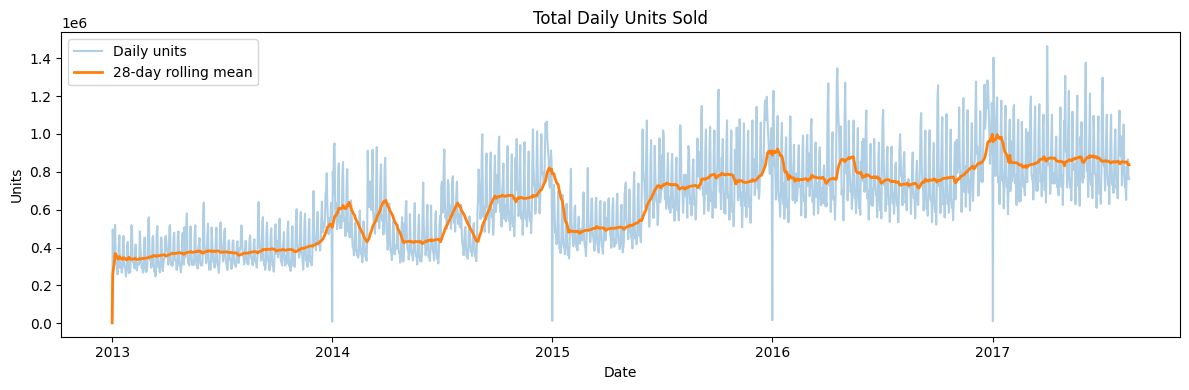

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(daily['date'], daily['units'], alpha=0.35, label='Daily units')
plt.plot(daily['date'], daily['rolling_28d'], linewidth=2, label='28-day rolling mean')
plt.title('Total Daily Units Sold')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation: use this chart to confirm trend direction and major seasonality spikes.

C:\Users\user\AppData\Local\Temp\ipykernel_40164\3200395538.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\user\Desktop\forecasting system\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


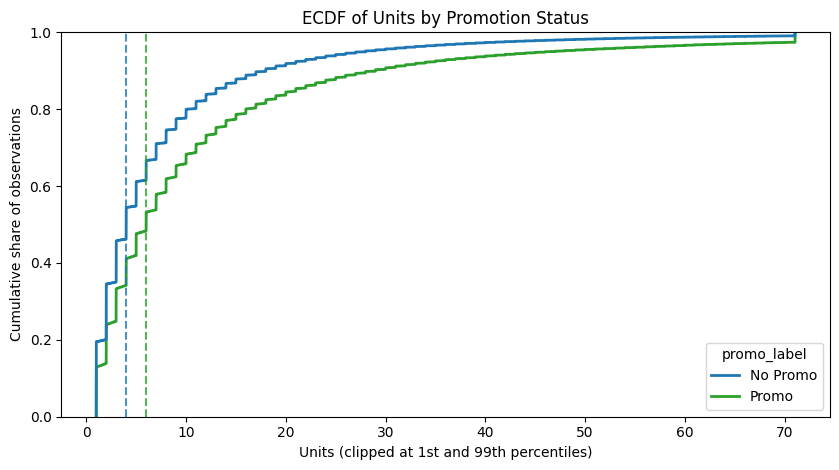

In [22]:
promo_plot = plot_df[['units', 'on_promotion']].dropna().copy()
promo_plot['on_promotion'] = promo_plot['on_promotion'].astype(bool)
clip_low = promo_plot['units'].quantile(0.01)
clip_high = promo_plot['units'].quantile(CLIP_QUANTILE)
promo_plot['units_clipped'] = promo_plot['units'].clip(lower=clip_low, upper=clip_high)
promo_plot['promo_label'] = promo_plot['on_promotion'].map({False: 'No Promo', True: 'Promo'})

plt.figure(figsize=(8.5, 4.8))
ax = sns.ecdfplot(
    data=promo_plot,
    x='units_clipped',
    hue='promo_label',
    linewidth=2,
    palette=['#1f77b4', '#2ca02c'],
    legend=True,
)

medians = promo_plot.groupby('promo_label')['units_clipped'].median()
for label, color in [('No Promo', '#1f77b4'), ('Promo', '#2ca02c')]:
    m = medians[label]
    plt.axvline(m, color=color, linestyle='--', alpha=0.8)

plt.title('ECDF of Units by Promotion Status')
plt.xlabel('Units (clipped at 1st and 99th percentiles)')
plt.ylabel('Cumulative share of observations')
handles, labels = ax.get_legend_handles_labels()
if labels:
    ax.legend(handles=handles, labels=labels, title='Promotion Status', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Interpretation: a right-shifted Promo curve (and higher promo median) suggests higher demand on promo days.

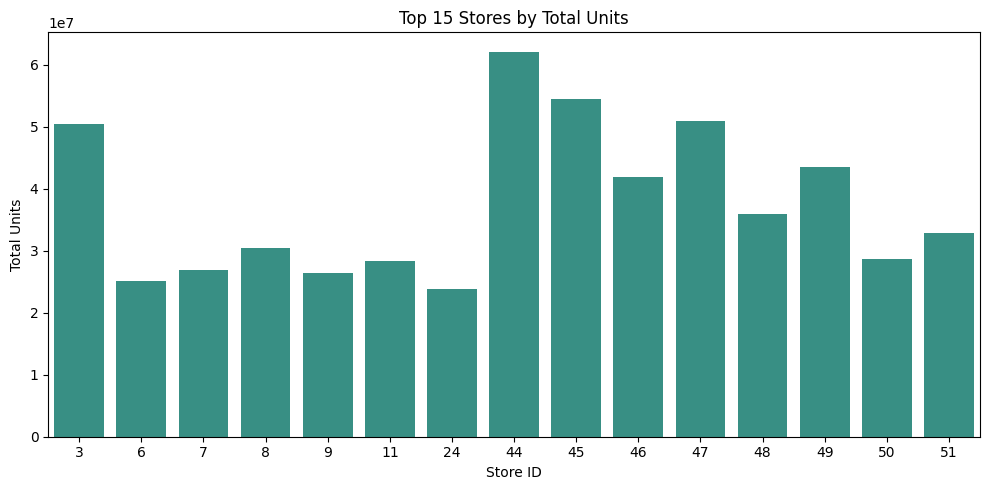

In [23]:
top_stores = (
    df.groupby('store_id', as_index=False)['units']
    .sum()
    .sort_values('units', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_stores, x='store_id', y='units', color='#2a9d8f')
plt.title('Top 15 Stores by Total Units')
plt.xlabel('Store ID')
plt.ylabel('Total Units')
plt.tight_layout()
plt.show()

# Interpretation: use this for concentration risk and top-store contribution.

In [24]:
segment_summary = (
    df.groupby(['cluster', 'perishable'], as_index=False)
    .agg(
        avg_units=('units', 'mean'),
        median_units=('units', 'median'),
        promo_rate=('on_promotion', 'mean'),
    )
    .sort_values('avg_units', ascending=False)
)

segment_summary.head(20)

,cluster,perishable,avg_units,median_units,promo_rate
9,5,1,25.504011,14.000,0.092653
21,11,1,19.420835,10.595,0.095673
15,8,1,16.227715,8.000,0.092031
33,17,1,16.072874,8.000,0.090180
8,5,0,14.792205,7.000,0.040847
27,14,1,13.735105,7.000,0.095880
20,11,0,12.157341,6.000,0.042779
26,14,0,11.222496,6.000,0.041736
23,12,1,9.964818,6.000,0.135370
11,6,1,9.354413,4.962,0.144427


### Additional Checks: Zero/Negative Sales and Segment Promo Lift

In [26]:
zero_negative_summary = (
    df.assign(
        is_zero=(df['units'] == 0).astype(int),
        is_negative=(df['units'] < 0).astype(int),
    )
    .groupby('cluster', as_index=False)
    .agg(
        rows=('units', 'size'),
        zero_rate=('is_zero', 'mean'),
        negative_rate=('is_negative', 'mean'),
        avg_units=('units', 'mean'),
    )
    .sort_values('negative_rate', ascending=False)
)

zero_negative_summary['zero_rate_pct'] = (zero_negative_summary['zero_rate'] * 100).round(2)
zero_negative_summary['negative_rate_pct'] = (zero_negative_summary['negative_rate'] * 100).round(2)

zero_negative_summary[['cluster', 'rows', 'zero_rate_pct', 'negative_rate_pct', 'avg_units']].head(20)

,cluster,rows,zero_rate_pct,negative_rate_pct,avg_units
15,16,2196682,0.0,0.02,6.030505
4,5,3513089,0.0,0.01,17.673206
16,17,2960031,0.0,0.01,11.118629
7,8,9583652,0.0,0.01,11.261392
10,11,7117356,0.0,0.01,14.136468
8,9,5196251,0.0,0.01,5.881371
12,13,10578047,0.0,0.01,6.814888
0,1,7458623,0.0,0.01,7.290453
1,2,4293374,0.0,0.01,6.734937
13,14,13240386,0.0,0.01,11.890176


In [27]:
promo_lift_by_cluster = (
    df.groupby(['cluster', 'on_promotion'], as_index=False)
    .agg(avg_units=('units', 'mean'), median_units=('units', 'median'))
)

promo_pivot = promo_lift_by_cluster.pivot(index='cluster', columns='on_promotion', values='avg_units')
promo_pivot = promo_pivot.rename(columns={False: 'avg_units_no_promo', True: 'avg_units_promo'})
promo_pivot = promo_pivot.reset_index()

promo_pivot['uplift_abs'] = promo_pivot['avg_units_promo'] - promo_pivot['avg_units_no_promo']
promo_pivot['uplift_pct'] = (
    100 * promo_pivot['uplift_abs'] / promo_pivot['avg_units_no_promo'].replace(0, np.nan)
).round(2)

promo_pivot.sort_values('uplift_pct', ascending=False).head(20)

on_promotion,cluster,avg_units_no_promo,avg_units_promo,uplift_abs,uplift_pct
16,17,10.637077,19.404711,8.767633,82.430000
4,5,16.934828,30.413639,13.478811,79.589996
3,4,5.996784,10.738924,4.742140,79.080002
7,8,10.823359,19.208841,8.385483,77.480003
10,11,13.540504,23.960960,10.420456,76.959999
0,1,6.996161,12.185634,5.189472,74.180000
2,3,6.072868,10.210435,4.137567,68.129997
1,2,6.452656,10.847406,4.394750,68.110001
15,16,5.790836,9.717212,3.926375,67.800003
9,10,6.664444,11.053974,4.389530,65.860001


## 8. Save Artifacts and Export Results

In [29]:
missing_table.to_csv(PLOTS_DIR / 'missing_table.csv', index=True)
segment_summary.to_csv(PLOTS_DIR / 'segment_summary.csv', index=False)
daily.tail(90).to_csv(PLOTS_DIR / 'daily_last_90_days.csv', index=False)

if 'zero_negative_summary' in globals():
    zero_negative_summary.to_csv(PLOTS_DIR / 'zero_negative_summary.csv', index=False)
if 'promo_pivot' in globals():
    promo_pivot.to_csv(PLOTS_DIR / 'promo_lift_by_cluster.csv', index=False)

print('Saved artifacts to:', PLOTS_DIR)
print('- missing_table.csv')
print('- segment_summary.csv')
print('- daily_last_90_days.csv')
print('- zero_negative_summary.csv')
print('- promo_lift_by_cluster.csv')

Saved artifacts to: c:\Users\user\Desktop\forecasting system\reports\eda_notebook
- missing_table.csv
- segment_summary.csv
- daily_last_90_days.csv
- zero_negative_summary.csv
- promo_lift_by_cluster.csv


### Findings Template

- Trend and seasonality:
- Promotion impact (lift or no lift):
- Highest-volume stores:
- Highest-risk data quality issue:
- Next modeling action: